# Day 2 - 세션 1 : AutoML로 콘크리트 압축강도 예측하기

## 📌 Day 1 복습

Day 1에서는 **베어링 센서 신호**를 이용해 "정상 / 고장(고장 종류)"을 구분하는 **분류(Classification)** 문제를 다뤘습니다.
- 입력: 진동 신호 (시계열 → FFT/주파수 특징)
- 출력: 4개 클래스 중 하나 (Normal, Inner Race, Outer Race, Ball)
- 모델: 1D-CNN, CNN-LSTM (딥러닝)

## 🎯 Day 2의 목표 : 회귀(Regression) 문제로 전환

오늘은 조금 다른 종류의 문제를 다룹니다.

> **"이 레시피(원료 비율)로 콘크리트를 만들면, 28일 후 압축강도가 몇 MPa이 나올까?"**

이번엔 클래스를 맞추는 게 아니라, **숫자(연속값)를 예측**하는 문제입니다. 이런 문제를 **회귀(Regression)**라고 부릅니다.

또한 이번 세션부터는 딥러닝 모델을 직접 코딩하는 대신, **AutoML 도구(PyCaret)**를 사용합니다.
현업에서 빠르게 "이 데이터로 머신러닝이 통할지" 검증할 때 매우 유용한 방식입니다.

## ✅ 세션 1 목표

1. 콘크리트 압축강도 데이터셋을 살펴보고, 변수들의 의미를 이해한다
2. 데이터의 분포와 변수 간 상관관계를 시각화로 확인한다
3. PyCaret으로 데이터 전처리를 자동화한다 (`setup()`)
4. 여러 머신러닝 모델을 한 번에 비교한다 (`compare_models()`)
5. 결과를 현장 기준(KS 규격)과 연결해서 해석한다


## STEP 1. 데이터셋 소개

오늘 사용할 데이터는 **UCI Concrete Compressive Strength** 데이터셋입니다.
콘크리트를 만들 때 섞는 **8가지 원료/조건**과, 그 결과로 나온 **28일 압축강도**가 기록되어 있습니다 (총 1030개 샘플).

### 입력 변수 (8개) - "레시피"

| 컬럼명 | 의미 | 단위 |
|---|---|---|
| `cement` | 시멘트 | kg/m³ |
| `blast_furnace_slag` | 고로 슬래그 (시멘트 대체 재료) | kg/m³ |
| `fly_ash` | 플라이애시 (석탄재, 혼합재) | kg/m³ |
| `water` | 물 | kg/m³ |
| `superplasticizer` | 고성능 감수제 (유동성 향상 첨가제) | kg/m³ |
| `coarse_aggregate` | 굵은 골재 (자갈) | kg/m³ |
| `fine_aggregate` | 잔골재 (모래) | kg/m³ |
| `age` | 양생 일수 | day |

### 출력 변수 (1개) - "결과"

| 컬럼명 | 의미 | 단위 |
|---|---|---|
| `concrete_compressive_strength` | 28일 압축강도 | MPa |

### 💡 현장 기준 참고

KS L 5201 (포틀랜드 시멘트 규격)에서는 **1종 시멘트의 28일 압축강도가 42.5 MPa 이상**이어야 합니다.
오늘 만드는 모델이 예측한 값이 이 기준을 기준으로 "쓸만한 정확도"인지 판단하는 데 사용해보겠습니다.


In [ ]:
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (OS별 한글 폰트 자동 설정)
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("concrete_data.csv")

# 컬럼명 앞뒤 공백 제거 (예: 'fine_aggregate ' -> 'fine_aggregate')
df.columns = df.columns.str.strip()

print(f"데이터 크기: {df.shape}")
df.head()

## STEP 2. 데이터 통계 살펴보기

`describe()`는 각 컬럼의 **개수, 평균, 표준편차, 최소/최대값, 사분위수**를 한눈에 보여줍니다.

특히 주목할 점:
- `age`(양생 일수)는 최소 1일 ~ 최대 365일까지 폭넓게 분포
- 일부 컬럼(`blast_furnace_slag`, `fly_ash`, `superplasticizer`)은 **최소값이 0** → 모든 콘크리트 레시피에 이 재료가 들어가는 건 아니라는 의미


In [2]:
df.describe()

,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


## STEP 3. 시각화로 데이터 감 잡기

본격적인 모델링 전에, 두 가지를 시각화로 확인합니다.

1. **목표 변수(압축강도)의 분포** - 어떤 범위의 값들이 많은지, KS 기준(42.5 MPa)과 비교했을 때 데이터가 어떻게 분포하는지
2. **변수 간 상관관계(Correlation)** - 어떤 입력 변수가 압축강도와 강하게 연관되어 있는지

### 상관관계(Correlation) 해석법

- 값의 범위: **-1 ~ +1**
- **+1에 가까움**: 한 변수가 커지면 다른 변수도 커짐 (양의 상관)
- **-1에 가까움**: 한 변수가 커지면 다른 변수는 작아짐 (음의 상관)
- **0에 가까움**: 두 변수 사이에 뚜렷한 선형 관계 없음

⚠️ 주의: 상관관계는 "**같이 움직이는 정도**"만 보여줄 뿐, **인과관계**를 의미하지 않습니다.


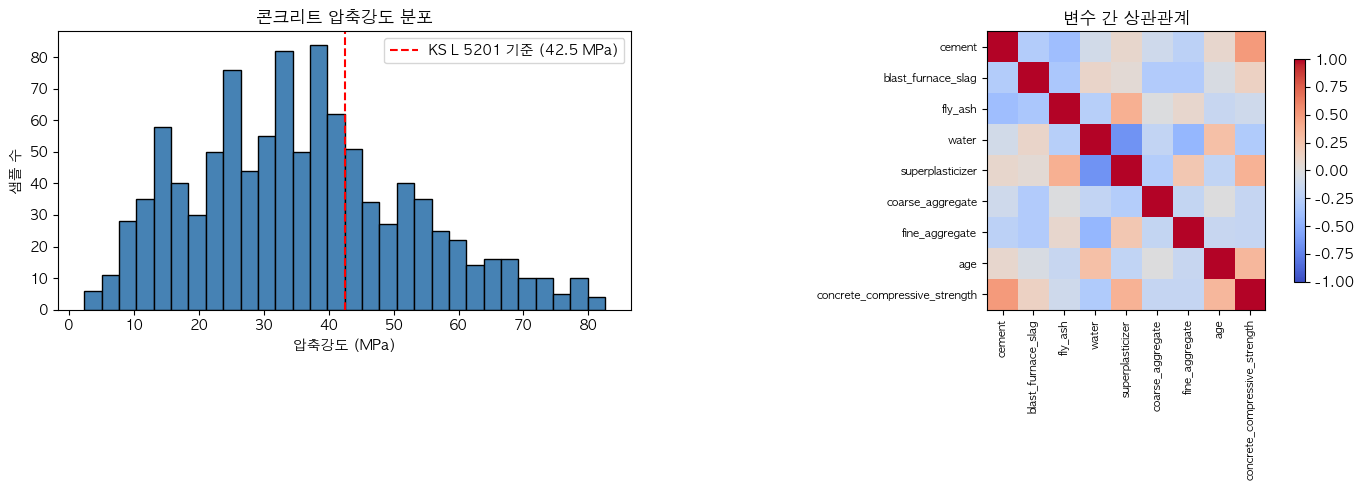

압축강도와 상관관계가 큰 변수 Top 3:
cement              0.497832
superplasticizer    0.366079
age                 0.328873
Name: concrete_compressive_strength, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 압축강도 분포 히스토그램
target_col = 'concrete_compressive_strength'
axes[0].hist(df[target_col], bins=30, color='steelblue', edgecolor='black')
axes[0].axvline(42.5, color='red', linestyle='--', label='KS L 5201 기준 (42.5 MPa)')
axes[0].set_title('콘크리트 압축강도 분포')
axes[0].set_xlabel('압축강도 (MPa)')
axes[0].set_ylabel('샘플 수')
axes[0].legend()

# (2) 변수 간 상관관계 히트맵
corr = df.corr()
im = axes[1].imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90, fontsize=8)
axes[1].set_yticklabels(corr.columns, fontsize=8)
axes[1].set_title('변수 간 상관관계')
fig.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

# 압축강도와 상관관계가 높은 변수 Top 3 출력
target_corr = corr[target_col].drop(target_col).sort_values(key=abs, ascending=False)
print("압축강도와 상관관계가 큰 변수 Top 3:")
print(target_corr.head(3))

## STEP 4. 왜 AutoML인가?

회귀 문제를 풀 수 있는 머신러닝 모델은 정말 많습니다: 선형회귀, 랜덤포레스트, XGBoost, LightGBM, 신경망 등...

**어떤 모델이 우리 데이터에 가장 잘 맞을지는, 직접 다 돌려보기 전까지는 알기 어렵습니다.**

### 🍳 비유: AutoML = 여러 셰프에게 같은 재료를 주고 요리를 시켜보기

같은 재료(데이터)를 여러 셰프(모델)에게 주고 요리(학습)를 시킨 뒤, 누구 요리가 가장 맛있는지(예측이 정확한지) 비교하는 것과 비슷합니다.

**PyCaret**은 이 과정을 자동화해주는 라이브러리입니다.
- 데이터 전처리(결측치 처리, 정규화, train/test 분리)를 자동으로 해주고
- 수십 개의 머신러닝 모델을 한 번에 학습/평가해서 비교해줍니다

코드 몇 줄로 "이 데이터에 머신러닝이 통할까?"를 빠르게 검증할 수 있습니다.


## STEP 5. PyCaret 환경 설정 - `setup()`

PyCaret을 쓰기 위한 첫 단계는 `setup()` 함수 호출입니다. 이 한 줄이 다음을 자동으로 처리합니다:

- 데이터를 **학습용(train) / 검증용(test)**으로 분리
- 결측치 처리, 수치형 변수 정규화 등 전처리
- 각 컬럼의 데이터 타입(수치형/범주형) 자동 인식

실행하면 아래와 같은 **설정 요약 테이블**이 출력됩니다. 주요 항목 해석:

| 항목 | 의미 |
|---|---|
| Session id | 실험 재현을 위한 랜덤 시드 |
| Target | 예측하고자 하는 변수 (`concrete_compressive_strength`) |
| Target type | Regression (회귀) |
| Original data shape | 원본 데이터 크기 |
| Transformed data shape | 전처리 후 데이터 크기 |
| Numeric features | 수치형 입력 변수 개수 |

`session_id`는 매번 같은 결과가 나오도록 고정하는 랜덤 시드입니다 (실험 재현성을 위해 고정).


In [4]:
from pycaret.regression import *

s = setup(data=df, target='concrete_compressive_strength', session_id=123)

,Description,Value
0,Session id,123
1,Target,concrete_compressive_strength
2,Target type,Regression
3,Original data shape,"(1030, 9)"
4,Transformed data shape,"(1030, 9)"
5,Transformed train set shape,"(721, 9)"
6,Transformed test set shape,"(309, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


## STEP 6. 모델 비교 - `compare_models()`

`compare_models()`를 호출하면, PyCaret이 등록된 모든 회귀 모델(선형회귀, 랜덤포레스트, XGBoost, LightGBM 등)을 학습시키고,
**교차검증(cross-validation)** 결과를 성능 좋은 순서로 정렬한 표로 보여줍니다.

### 주요 평가지표

| 지표 | 의미 | 좋은 방향 |
|---|---|---|
| **R²** | 모델이 데이터의 분산을 얼마나 잘 설명하는지 (1에 가까울수록 좋음) | ↑ 클수록 좋음 |
| **RMSE** | 평균 오차 크기 (실제값과 같은 단위, MPa) - 큰 오차에 더 민감 | ↓ 작을수록 좋음 |
| **MAE** | 평균 절대 오차 (MPa) | ↓ 작을수록 좋음 |

### 💡 "쓸만한 모델인가?" 판단하기

예를 들어 RMSE가 4 MPa라면, 평균적으로 예측값이 실제값과 **±4 MPa** 정도 차이가 난다는 뜻입니다.
KS 기준이 42.5 MPa인 상황에서, 이 정도 오차가 "기준 통과 여부를 가를 정도로 큰 오차인지" 현장 맥락에서 판단해봐야 합니다.

(참고: 이 실행은 약 10초 정도 걸립니다.)


In [5]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.2006,21.9523,4.6356,0.9215,0.1511,0.1106,0.1780
et,Extra Trees Regressor,3.2530,23.4571,4.7985,0.9166,0.1527,0.1128,0.0150
gbr,Gradient Boosting Regressor,3.7650,27.6610,5.2383,0.9007,0.1634,0.1295,0.0120
rf,Random Forest Regressor,3.6619,28.2038,5.2328,0.8993,0.1679,0.1290,0.0210
dt,Decision Tree Regressor,4.5467,43.9027,6.5348,0.8442,0.2165,0.1580,0.0030
ada,AdaBoost Regressor,6.1832,57.2779,7.5252,0.7944,0.2782,0.2605,0.0100
knn,K Neighbors Regressor,7.4127,94.3747,9.6708,0.6625,0.3208,0.2894,0.0050
ridge,Ridge Regression,8.3627,113.1336,10.6141,0.5892,0.3398,0.3216,0.0030
lar,Least Angle Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.0030
lr,Linear Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.2700


## STEP 7. 결과 해석하기

`compare_models()`가 출력한 표는 화면에 보여지는 것뿐, 코드로 다시 활용하려면 `pull()`로 표 자체를 DataFrame으로 가져올 수 있습니다.

또한 `best_model` 변수에는 **1위 모델 객체**가 자동으로 저장되어 있습니다.

### 모델을 선택하는 기준은 "1위"만이 아닙니다

- **정확도가 1위인 모델**이 항상 최선은 아닙니다.
- 학습/예측 속도(`TT (Sec)`)가 중요한 경우 → 약간 덜 정확해도 빠른 모델 선택
- 모델의 동작을 설명해야 하는 경우(해석성) → 복잡한 모델보다 단순한 모델 선택

다음 세션(세션 2)에서 이 "해석 가능성" 문제를 더 자세히 다룹니다.


In [6]:
results_df = pull()

print("1위 모델:", best_model)
print()
results_df[['Model', 'MAE', 'RMSE', 'R2', 'TT (Sec)']]

1위 모델: LGBMRegressor(n_jobs=-1, random_state=123)



,Model,MAE,RMSE,R2,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.2006,4.6356,0.9215,0.178
et,Extra Trees Regressor,3.2530,4.7985,0.9166,0.015
gbr,Gradient Boosting Regressor,3.7650,5.2383,0.9007,0.012
rf,Random Forest Regressor,3.6619,5.2328,0.8993,0.021
dt,Decision Tree Regressor,4.5467,6.5348,0.8442,0.003
ada,AdaBoost Regressor,6.1832,7.5252,0.7944,0.010
knn,K Neighbors Regressor,7.4127,9.6708,0.6625,0.005
ridge,Ridge Regression,8.3627,10.6141,0.5892,0.003
lar,Least Angle Regression,8.3627,10.6141,0.5892,0.003
lr,Linear Regression,8.3627,10.6141,0.5892,0.270


## STEP 8. 현장 기준과 연결해서 생각해보기

> 1위 모델의 RMSE가 약 4~5 MPa 정도라면, 이는 **KS 기준(42.5 MPa)의 약 10% 수준**의 오차입니다.

### 🤔 토론해보기

- 이 모델을 "배합 설계 단계에서 강도를 사전에 예측해보는 참고용 도구"로 쓴다면, 이 정도 오차는 받아들일 만할까요?
- 반대로 "이 모델 예측값만 보고 품질 검사를 생략해도 된다"고 하면 어떨까요?
- 오차가 항상 양수 방향(과대 예측)이거나 음수 방향(과소 예측)으로 치우쳐 있다면, 어떤 방향의 오차가 더 위험할까요? (강도를 과대평가하는 것 vs 과소평가하는 것)

AutoML 모델은 "사람의 최종 판단을 보조하는 도구"로 보는 것이 안전합니다.


## STEP 9. 실습 - Top 3 모델 비교하기

`compare_models()`는 `n_select` 옵션을 주면, 1위 모델뿐 아니라 **상위 N개 모델을 리스트로 반환**합니다.

이번엔 상위 3개 모델을 받아서, 각 모델이 무엇인지와 성능을 함께 확인해봅시다.


In [7]:
top3_models = compare_models(n_select=3)
top3_df = pull()

print("Top 3 모델:")
for m in top3_models:
    print(" -", m)

print()
top3_df[['Model', 'MAE', 'RMSE', 'R2', 'TT (Sec)']].head(3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.2006,21.9523,4.6356,0.9215,0.1511,0.1106,0.1820
et,Extra Trees Regressor,3.2530,23.4571,4.7985,0.9166,0.1527,0.1128,0.0150
gbr,Gradient Boosting Regressor,3.7650,27.6610,5.2383,0.9007,0.1634,0.1295,0.0110
rf,Random Forest Regressor,3.6619,28.2038,5.2328,0.8993,0.1679,0.1290,0.0220
dt,Decision Tree Regressor,4.5467,43.9027,6.5348,0.8442,0.2165,0.1580,0.0020
ada,AdaBoost Regressor,6.1832,57.2779,7.5252,0.7944,0.2782,0.2605,0.0090
knn,K Neighbors Regressor,7.4127,94.3747,9.6708,0.6625,0.3208,0.2894,0.0050
ridge,Ridge Regression,8.3627,113.1336,10.6141,0.5892,0.3398,0.3216,0.0030
lar,Least Angle Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.0030
lr,Linear Regression,8.3627,113.1337,10.6141,0.5892,0.3398,0.3216,0.0030


Top 3 모델:
 - LGBMRegressor(n_jobs=-1, random_state=123)
 - ExtraTreesRegressor(n_jobs=-1, random_state=123)
 - GradientBoostingRegressor(random_state=123)



,Model,MAE,RMSE,R2,TT (Sec)
lightgbm,Light Gradient Boosting Machine,3.2006,4.6356,0.9215,0.182
et,Extra Trees Regressor,3.2530,4.7985,0.9166,0.015
gbr,Gradient Boosting Regressor,3.7650,5.2383,0.9007,0.011


## 📝 세션 1 정리

오늘 진행한 과정을 한눈에 정리하면:

```
원본 데이터 (concrete_data.csv)
        ↓
   setup()  → 전처리 자동화 (train/test 분리, 정규화 등)
        ↓
compare_models()  → 수십 개 모델을 한 번에 학습 & 비교
        ↓
   결과 표 (R², RMSE, MAE)  → 현장 기준(KS 42.5 MPa)과 비교 해석
```

### ✅ 산출물

- PyCaret으로 학습한 **Top 3 모델 비교표**
- 압축강도 예측에 가장 적합한 모델 후보

### 🔮 다음 세션 예고

1위 모델이 나왔다고 끝이 아닙니다.
- 이 모델은 **"왜" 그렇게 예측**했을까요? (해석 가능성)
- 더 성능을 끌어올릴 방법은 없을까요? (하이퍼파라미터 튜닝)

세션 2에서 이어서 다룹니다.
